In [ ]:
# Librerías
pandas as pd
numpy as np
scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from scipy.stats import skew, kurtosis, boxcox
from sklearn.impute import KNNImputer

In [ ]:
# 1. Cargar el dataset usando el delimitador ';' identificado en el archivo
df = pd.read_csv('dataset_procesado.csv', sep=';', encoding='latin1')

# 2. Limpiar nombres de columnas (eliminar espacios en blanco al inicio/final)
df.columns = df.columns.str.strip()

# 3. Mostrar las primeras filas y la estructura general
print("--- Información General del Dataset ---")
print(df.info())
display(df.head())

--- Información General del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1152 entries, 0 to 1151
Data columns (total 12 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   Empresa                                                             1152 non-null   object 
 1   Departamento                                                        1152 non-null   object 
 2   Municipio                                                           1152 non-null   object 
 3   Número único de identificación del sistema de tratamiento (NUPTAR)  1152 non-null   int64  
 4   Caudal medio anual a la entrada (L/S)                               1152 non-null   float64
 5   Caudal medio anual a la salida (LTS/SG)                             1152 non-null   float64
 6   pH Unidades                                                         1152

,Empresa,Departamento,Municipio,Número único de identificación del sistema de tratamiento (NUPTAR),Caudal medio anual a la entrada (L/S),Caudal medio anual a la salida (LTS/SG),pH Unidades,Temperatura (°C),Sóidos Totales (mg/litro),DBO (Kg/Día),DQO (Kg/Día,Fecha de cargue
0,ACUEDUCTO ALCANTARILLADO Y ASEO DE COCONUCO S....,CAUCA,PURACE,4405,0.00,0.000,0.00,0.0,0.0,0.0,0.0,22-may-25
1,ACUEDUCTOS Y ALCANTARILLADOS SOSTENIBLES A.A.S...,ANTIOQUIA,AMALFI,2342,14.40,14.400,7.16,21.8,481.0,103.2,267.0,20-mar-25
2,ACUEDUCTOS Y ALCANTARILLADOS SOSTENIBLES A.A.S...,ANTIOQUIA,AMALFI,2343,17.70,17.700,6.99,19.2,537.0,170.9,364.0,20-mar-25
3,ACUEDUCTOS Y ALCANTARILLADOS SOSTENIBLES A.A.S...,ANTIOQUIA,AMALFI,2344,10.02,9.837,7.13,17.3,302.0,76.7,136.0,20-mar-25
4,ACUEDUCTOS Y ALCANTARILLADOS SOSTENIBLES A.A.S...,ANTIOQUIA,AMALFI,2345,3.54,3.540,6.93,23.8,259.0,30.9,104.0,20-mar-25


Observando de manera general esa primera impresión de la base de datos se evidencia que hay registros donde el valor de agunas variables es cero, situación que es imposible para las pruebas fisicoquímicas relacionadas con la calidad del agua, es por ello que lo primero que se hace es transformar esos ceros en valores faltantes:

In [ ]:
# 1. Lista de columnas que NO pueden ser cero físicamente
cols_criticas = [
    'Caudal medio anual a la entrada (L/S)',
    'pH Unidades',
    'Temperatura (°C)',
    'DBO (Kg/Día)',
    'DQO (Kg/Día',
    'Sóidos Totales (mg/litro)'
]

for col in cols_criticas:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("--- Conteo de Valores en Cero (Columnas Críticas) ---")
for col in cols_criticas:
    ceros = (df[col] == 0).sum()
    porcentaje = (ceros / len(df)) * 100
    print(f"{col}: {ceros} ceros ({porcentaje:.2f}%)")

# 2. Reemplazar ceros por NaN (Not a Number) para que no afecten los promedios
df_limpio = df.copy()
for col in cols_criticas:
    df_limpio[col] = df_limpio[col].replace(0, np.nan)

# 3. Ver cuántos datos hay perdidos por variable
print("\nDatos nulos detectados después de tratar los ceros:")
print(df_limpio[cols_criticas].isnull().sum())


--- Conteo de Valores en Cero (Columnas Críticas) ---
Caudal medio anual a la entrada (L/S): 40 ceros (3.47%)
pH Unidades: 67 ceros (5.82%)
Temperatura (°C): 67 ceros (5.82%)
DBO (Kg/Día): 52 ceros (4.51%)
DQO (Kg/Día: 54 ceros (4.69%)
Sóidos Totales (mg/litro): 64 ceros (5.56%)

Datos nulos detectados después de tratar los ceros:
Caudal medio anual a la entrada (L/S)    40
pH Unidades                              67
Temperatura (°C)                         67
DBO (Kg/Día)                             52
DQO (Kg/Día                              54
Sóidos Totales (mg/litro)                64
dtype: int64


Solucionado el tema de los datos registrados como ceros se procede a hacer la exploración de los datos. Lo primero y que es relevante es la cantidad de datos que se registran por departamento.

--- Cantidad de PTAR reportadas por Departamento ---
Departamento
ATLANTICO             300
ANTIOQUIA             259
VALLE                 161
CORDOBA               128
LA GUAJIRA             73
CUNDINAMARCA           56
CALDAS                 40
MAGDALENA              22
QUINDIO                19
META                   15
SANTANDER              14
SUCRE                   9
CESAR                   9
BOYACA                  8
BOLIVAR                 7
D.C.                    6
TOLIMA                  6
CASANARE                5
CAUCA                   4
ARAUCA                  4
NARIÑO                  3
NORTE DE SANTANDER      1
CHOCO                   1
HUILA                   1
SAN ANDRES              1
Name: count, dtype: int64


/tmp/ipykernel_4443/4043306264.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cantidad de PTARs', y='Departamento', data=conteo_df, palette='viridis')


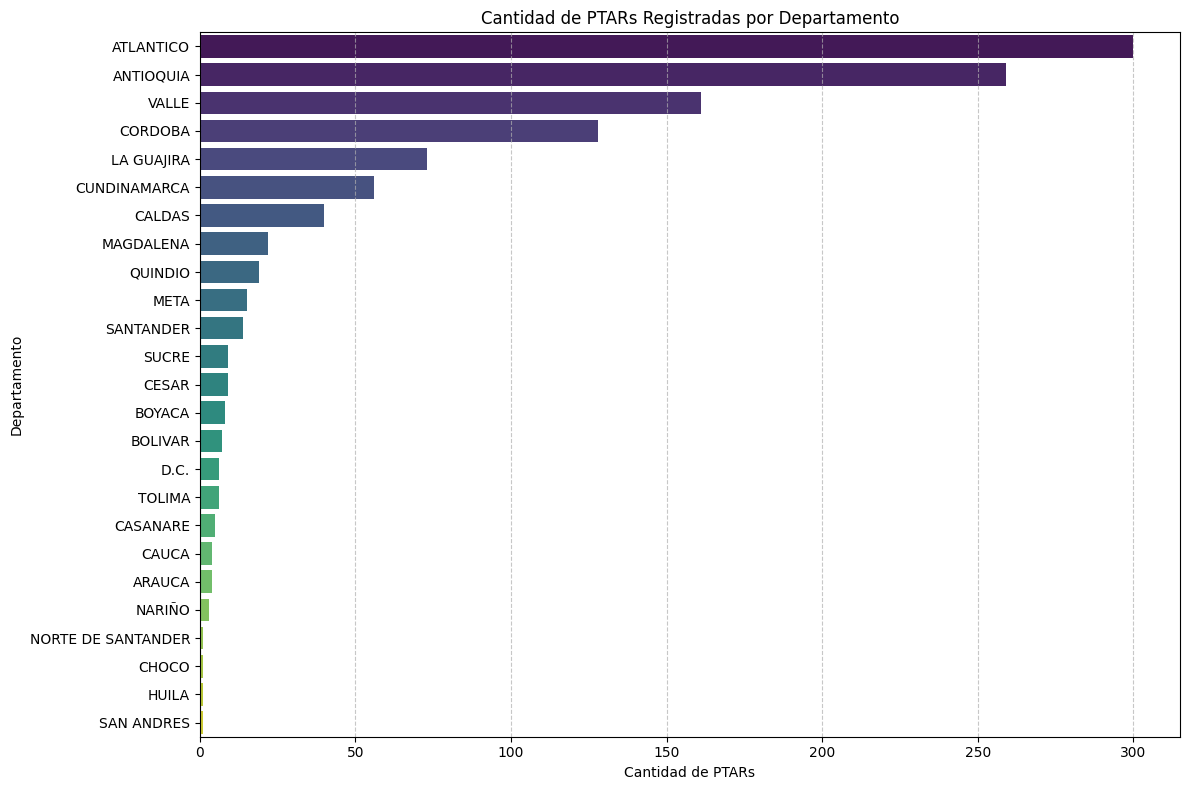

In [ ]:
print("--- Cantidad de PTAR reportadas por Departamento ---")
conteo_geo = df['Departamento'].value_counts()
print(conteo_geo)

import matplotlib.pyplot as plt
import seaborn as sns

# Convertir la serie conteo_geo a un DataFrame para facilitar el trazado con seaborn
conteo_df = conteo_geo.reset_index()
conteo_df.columns = ['Departamento', 'Cantidad de PTARs']

# Ordenar los datos por la cantidad de PTARs de mayor a menor para una mejor visualización
conteo_df = conteo_df.sort_values(by='Cantidad de PTARs', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Cantidad de PTARs', y='Departamento', data=conteo_df, palette='viridis')
plt.title('Cantidad de PTARs Registradas por Departamento')
plt.xlabel('Cantidad de PTARs')
plt.ylabel('Departamento')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Análisis univariado
Primero se presentan las medidas de dispersión para las variables involucradas con la calidad de los procesos y así tener un primer accercamiento a la base de datos.

DQO

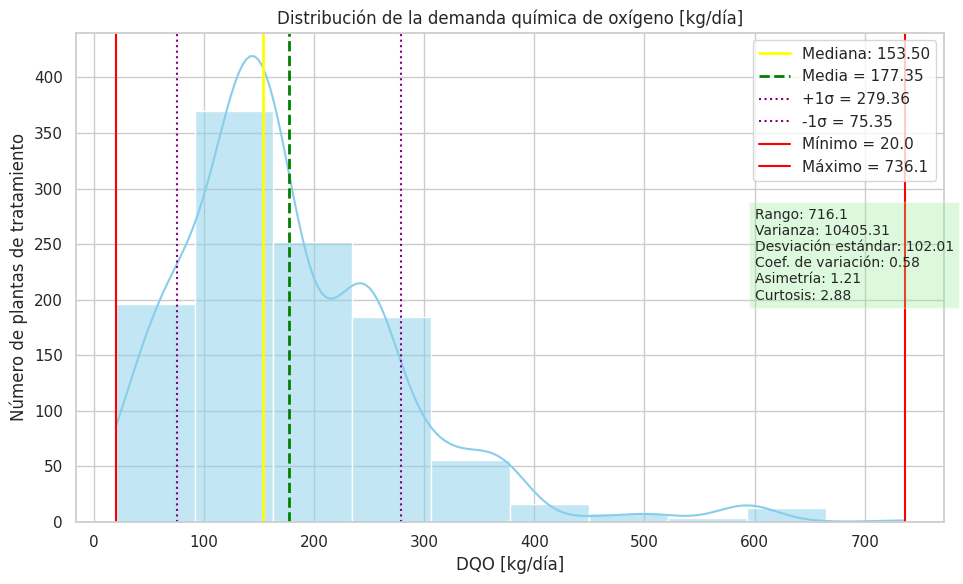

In [ ]:
# Cálculo de medidas de dispersión
media = np.mean(df_limpio['DQO (Kg/Día'])
minimo = np.min(df_limpio['DQO (Kg/Día'])
maximo = np.max(df_limpio['DQO (Kg/Día'])
rango = maximo - minimo
varianza = np.var(df_limpio['DQO (Kg/Día'], ddof=1)
desviacion = np.std(df_limpio['DQO (Kg/Día'], ddof=1)
coef_var = desviacion / media

# Mediana
mediana = df_limpio['DQO (Kg/Día'].median()

# Asimetría y curtosis
asimetria = skew(df['DQO (Kg/Día'])
curtosis_valor = kurtosis(df['DQO (Kg/Día'], fisher=True)  # Fisher=True: curtosis centrada en 0

# Visualización
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df_limpio['DQO (Kg/Día'], bins=10, kde=True, color='skyblue')

plt.axvline(mediana, color='yellow', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
plt.axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'+1σ = {media + desviacion:.2f}')
plt.axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'-1σ = {media - desviacion:.2f}')
plt.axvline(minimo, color='red', linestyle='-', linewidth=1.5, label=f'Mínimo = {minimo}')
plt.axvline(maximo, color='red', linestyle='-', linewidth=1.5, label=f'Máximo = {maximo}')

plt.title("Distribución de la demanda química de oxígeno [kg/día]")
plt.xlabel("DQO [kg/día]")
plt.ylabel("Número de plantas de tratamiento")
plt.legend(loc='upper right')

# Recuadro con medidas
texto = (
    f"Rango: {rango}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}\n"
    f"Asimetría: {asimetria:.2f}\n"
    f"Curtosis: {curtosis_valor:.2f}"
)
plt.text(600, 200, texto, bbox=dict(facecolor='lightgreen', alpha=0.3), fontsize=10)

plt.tight_layout()
plt.show()

Caudal

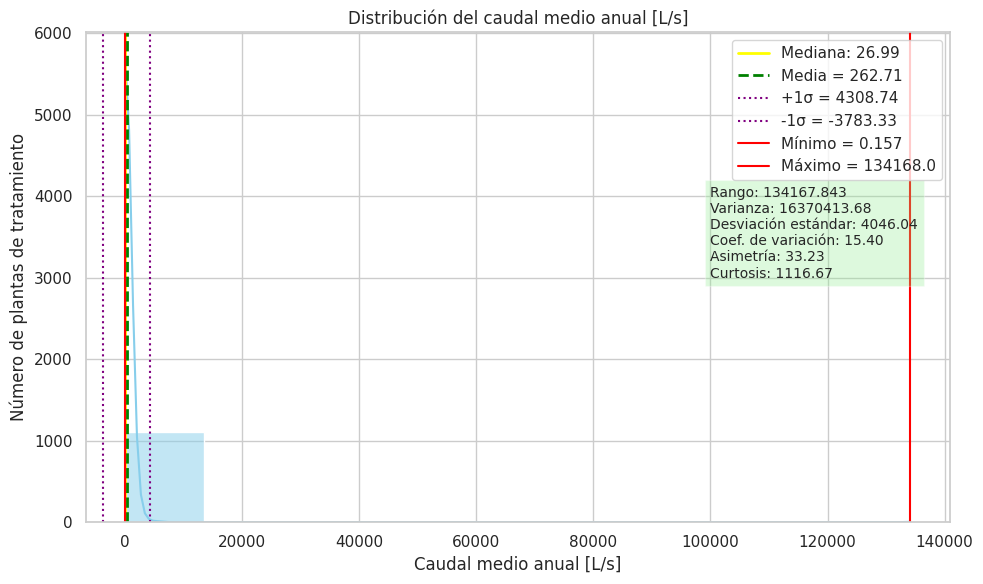

In [ ]:
# Cálculo de medidas de dispersión
media = np.mean(df_limpio['Caudal medio anual a la entrada (L/S)'])
minimo = np.min(df_limpio['Caudal medio anual a la entrada (L/S)'])
maximo = np.max(df_limpio['Caudal medio anual a la entrada (L/S)'])
rango = maximo - minimo
varianza = np.var(df_limpio['Caudal medio anual a la entrada (L/S)'], ddof=1)
desviacion = np.std(df_limpio['Caudal medio anual a la entrada (L/S)'], ddof=1)
coef_var = desviacion / media

# Mediana
mediana = df_limpio['Caudal medio anual a la entrada (L/S)'].median()

# Asimetría y curtosis
asimetria = skew(df['Caudal medio anual a la entrada (L/S)'])
curtosis_valor = kurtosis(df['Caudal medio anual a la entrada (L/S)'], fisher=True)  # Fisher=True: curtosis centrada en 0

# Visualización
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df_limpio['Caudal medio anual a la entrada (L/S)'], bins=10, kde=True, color='skyblue')

plt.axvline(mediana, color='yellow', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
plt.axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'+1σ = {media + desviacion:.2f}')
plt.axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'-1σ = {media - desviacion:.2f}')
plt.axvline(minimo, color='red', linestyle='-', linewidth=1.5, label=f'Mínimo = {minimo}')
plt.axvline(maximo, color='red', linestyle='-', linewidth=1.5, label=f'Máximo = {maximo}')

plt.title("Distribución del caudal medio anual [L/s]")
plt.xlabel("Caudal medio anual [L/s]")
plt.ylabel("Número de plantas de tratamiento")
plt.legend(loc='upper right')

# Recuadro con medidas
texto = (
    f"Rango: {rango}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}\n"
    f"Asimetría: {asimetria:.2f}\n"
    f"Curtosis: {curtosis_valor:.2f}"
)
plt.text(100000, 3000, texto, bbox=dict(facecolor='lightgreen', alpha=0.3), fontsize=10)

plt.tight_layout()
plt.show()

pH

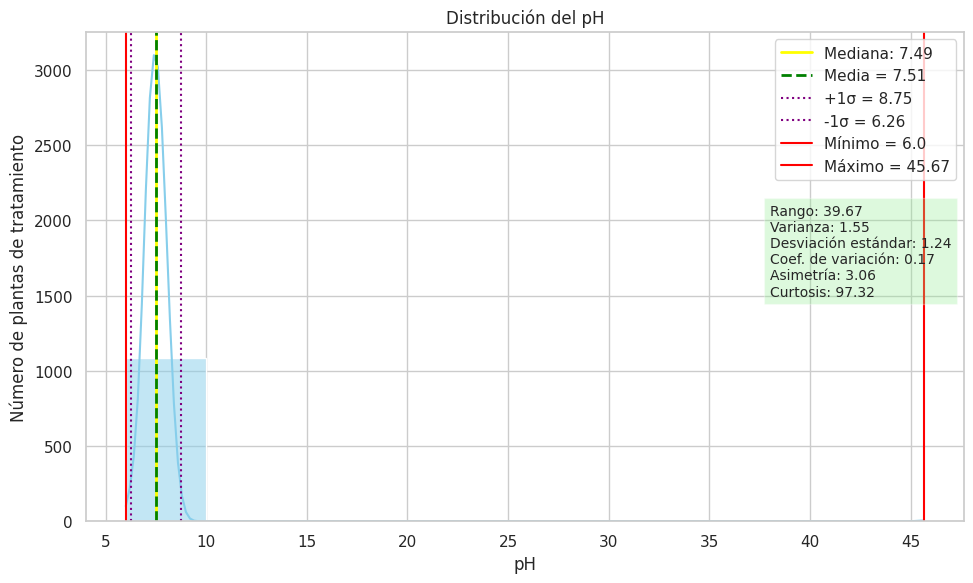

In [ ]:
# Cálculo de medidas de dispersión
media = np.mean(df_limpio['pH Unidades'])
minimo = np.min(df_limpio['pH Unidades'])
maximo = np.max(df_limpio['pH Unidades'])
rango = maximo - minimo
varianza = np.var(df_limpio['pH Unidades'], ddof=1)
desviacion = np.std(df_limpio['pH Unidades'], ddof=1)
coef_var = desviacion / media

# Mediana
mediana = df_limpio['pH Unidades'].median()

# Asimetría y curtosis
asimetria = skew(df['pH Unidades'])
curtosis_valor = kurtosis(df['pH Unidades'], fisher=True)  # Fisher=True: curtosis centrada en 0

# Visualización
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df_limpio['pH Unidades'], bins=10, kde=True, color='skyblue')

plt.axvline(mediana, color='yellow', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
plt.axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'+1σ = {media + desviacion:.2f}')
plt.axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'-1σ = {media - desviacion:.2f}')
plt.axvline(minimo, color='red', linestyle='-', linewidth=1.5, label=f'Mínimo = {minimo}')
plt.axvline(maximo, color='red', linestyle='-', linewidth=1.5, label=f'Máximo = {maximo}')

plt.title("Distribución del pH")
plt.xlabel("pH")
plt.ylabel("Número de plantas de tratamiento")
plt.legend(loc='upper right')

# Recuadro con medidas
texto = (
    f"Rango: {rango}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}\n"
    f"Asimetría: {asimetria:.2f}\n"
    f"Curtosis: {curtosis_valor:.2f}"
)
plt.text(38, 1500, texto, bbox=dict(facecolor='lightgreen', alpha=0.3), fontsize=10)

plt.tight_layout()
plt.show()

Temperatura

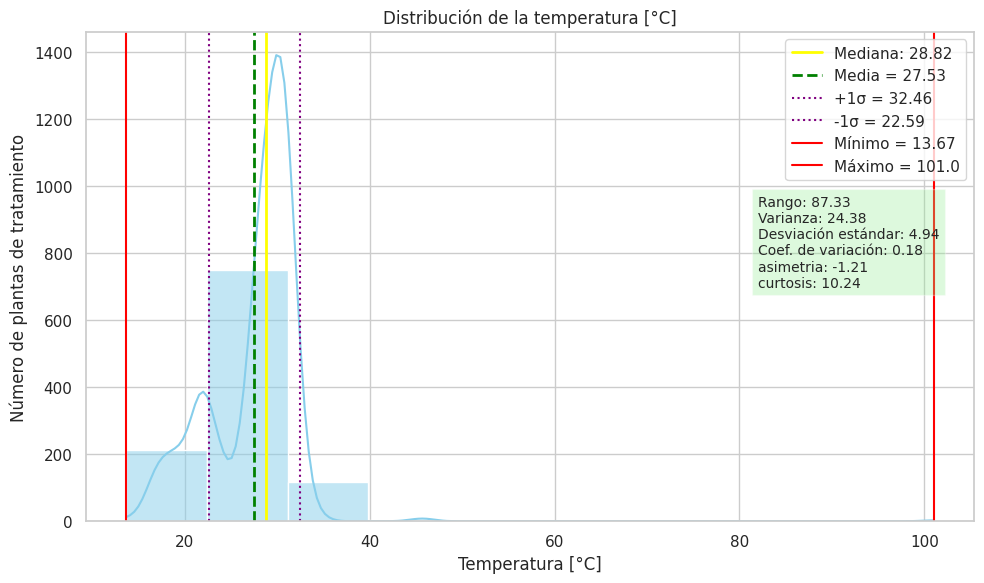

In [ ]:
# Cálculo de medidas de dispersión
media = np.mean(df_limpio['Temperatura (°C)'])
minimo = np.min(df_limpio['Temperatura (°C)'])
maximo = np.max(df_limpio['Temperatura (°C)'])
rango = maximo - minimo
varianza = np.var(df_limpio['Temperatura (°C)'], ddof=1)
desviacion = np.std(df_limpio['Temperatura (°C)'], ddof=1)
coef_var = desviacion / media

# Mediana
mediana = df_limpio['Temperatura (°C)'].median()

# Asimetría y curtosis
asimetria = skew(df['Temperatura (°C)'])
curtosis_valor = kurtosis(df['Temperatura (°C)'], fisher=True)  # Fisher=True: curtosis centrada en 0

# Visualización
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df_limpio['Temperatura (°C)'], bins=10, kde=True, color='skyblue')

plt.axvline(mediana, color='yellow', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
plt.axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'+1σ = {media + desviacion:.2f}')
plt.axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'-1σ = {media - desviacion:.2f}')
plt.axvline(minimo, color='red', linestyle='-', linewidth=1.5, label=f'Mínimo = {minimo}')
plt.axvline(maximo, color='red', linestyle='-', linewidth=1.5, label=f'Máximo = {maximo}')

plt.title("Distribución de la temperatura [°C]")
plt.xlabel("Temperatura [°C]")
plt.ylabel("Número de plantas de tratamiento")
plt.legend(loc='upper right')

# Recuadro con medidas
texto = (
    f"Rango: {rango}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}\n"
    f"asimetria: {asimetria:.2f}\n"
    f"curtosis: {curtosis_valor:.2f}"
)
plt.text(82, 700, texto, bbox=dict(facecolor='lightgreen', alpha=0.3), fontsize=10)

plt.tight_layout()
plt.show()

DBO

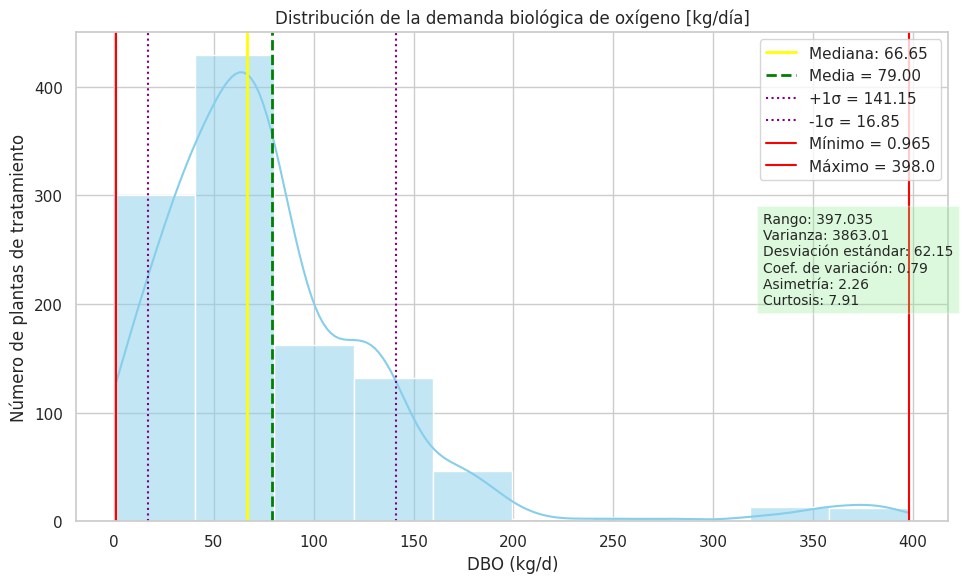

In [ ]:
# Cálculo de medidas de dispersión
media = np.mean(df_limpio['DBO (Kg/Día)'])
minimo = np.min(df_limpio['DBO (Kg/Día)'])
maximo = np.max(df_limpio['DBO (Kg/Día)'])
rango = maximo - minimo
varianza = np.var(df_limpio['DBO (Kg/Día)'], ddof=1)
desviacion = np.std(df_limpio['DBO (Kg/Día)'], ddof=1)
coef_var = desviacion / media

# Mediana
mediana = df_limpio['DBO (Kg/Día)'].median()

# Asimetría y curtosis
asimetria = skew(df['DBO (Kg/Día)'])
curtosis_valor = kurtosis(df['DBO (Kg/Día)'], fisher=True)  # Fisher=True: curtosis centrada en 0

# Visualización
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df_limpio['DBO (Kg/Día)'], bins=10, kde=True, color='skyblue')

plt.axvline(mediana, color='yellow', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
plt.axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'+1σ = {media + desviacion:.2f}')
plt.axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'-1σ = {media - desviacion:.2f}')
plt.axvline(minimo, color='red', linestyle='-', linewidth=1.5, label=f'Mínimo = {minimo}')
plt.axvline(maximo, color='red', linestyle='-', linewidth=1.5, label=f'Máximo = {maximo}')

plt.title("Distribución de la demanda biológica de oxígeno [kg/día]")
plt.xlabel("DBO (kg/d)")
plt.ylabel("Número de plantas de tratamiento")
plt.legend(loc='upper right')

# Recuadro con medidas
texto = (
    f"Rango: {rango}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}\n"
    f"Asimetría: {asimetria:.2f}\n"
    f"Curtosis: {curtosis_valor:.2f}"
)
plt.text(325, 200, texto, bbox=dict(facecolor='lightgreen', alpha=0.3), fontsize=10)

plt.tight_layout()
plt.show()

Sólidos totales

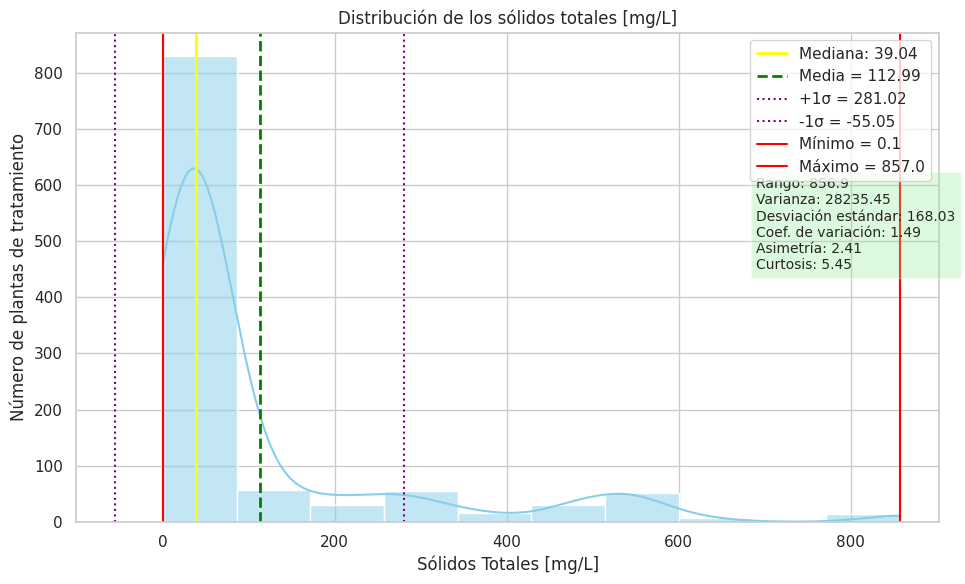

In [ ]:
# Cálculo de medidas de dispersión
media = np.mean(df_limpio['Sóidos Totales (mg/litro)'])
minimo = np.min(df_limpio['Sóidos Totales (mg/litro)'])
maximo = np.max(df_limpio['Sóidos Totales (mg/litro)'])
rango = maximo - minimo
varianza = np.var(df_limpio['Sóidos Totales (mg/litro)'], ddof=1)
desviacion = np.std(df_limpio['Sóidos Totales (mg/litro)'], ddof=1)
coef_var = desviacion / media

# Mediana
mediana = df_limpio['Sóidos Totales (mg/litro)'].median()

# Asimetría y curtosis
asimetria = skew(df['Sóidos Totales (mg/litro)'])
curtosis_valor = kurtosis(df['Sóidos Totales (mg/litro)'], fisher=True)  # Fisher=True: curtosis centrada en 0

# Visualización
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df_limpio['Sóidos Totales (mg/litro)'], bins=10, kde=True, color='skyblue')

plt.axvline(mediana, color='yellow', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
plt.axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'+1σ = {media + desviacion:.2f}')
plt.axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'-1σ = {media - desviacion:.2f}')
plt.axvline(minimo, color='red', linestyle='-', linewidth=1.5, label=f'Mínimo = {minimo}')
plt.axvline(maximo, color='red', linestyle='-', linewidth=1.5, label=f'Máximo = {maximo}')

plt.title("Distribución de los sólidos totales [mg/L]")
plt.xlabel("Sólidos Totales [mg/L]")
plt.ylabel("Número de plantas de tratamiento")
plt.legend(loc='upper right')

# Recuadro con medidas
texto = (
    f"Rango: {rango}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}\n"
    f"Asimetría: {asimetria:.2f}\n"
    f"Curtosis: {curtosis_valor:.2f}"
)
plt.text(690, 450, texto, bbox=dict(facecolor='lightgreen', alpha=0.3), fontsize=10)

plt.tight_layout()
plt.show()

# Análisis multivariado

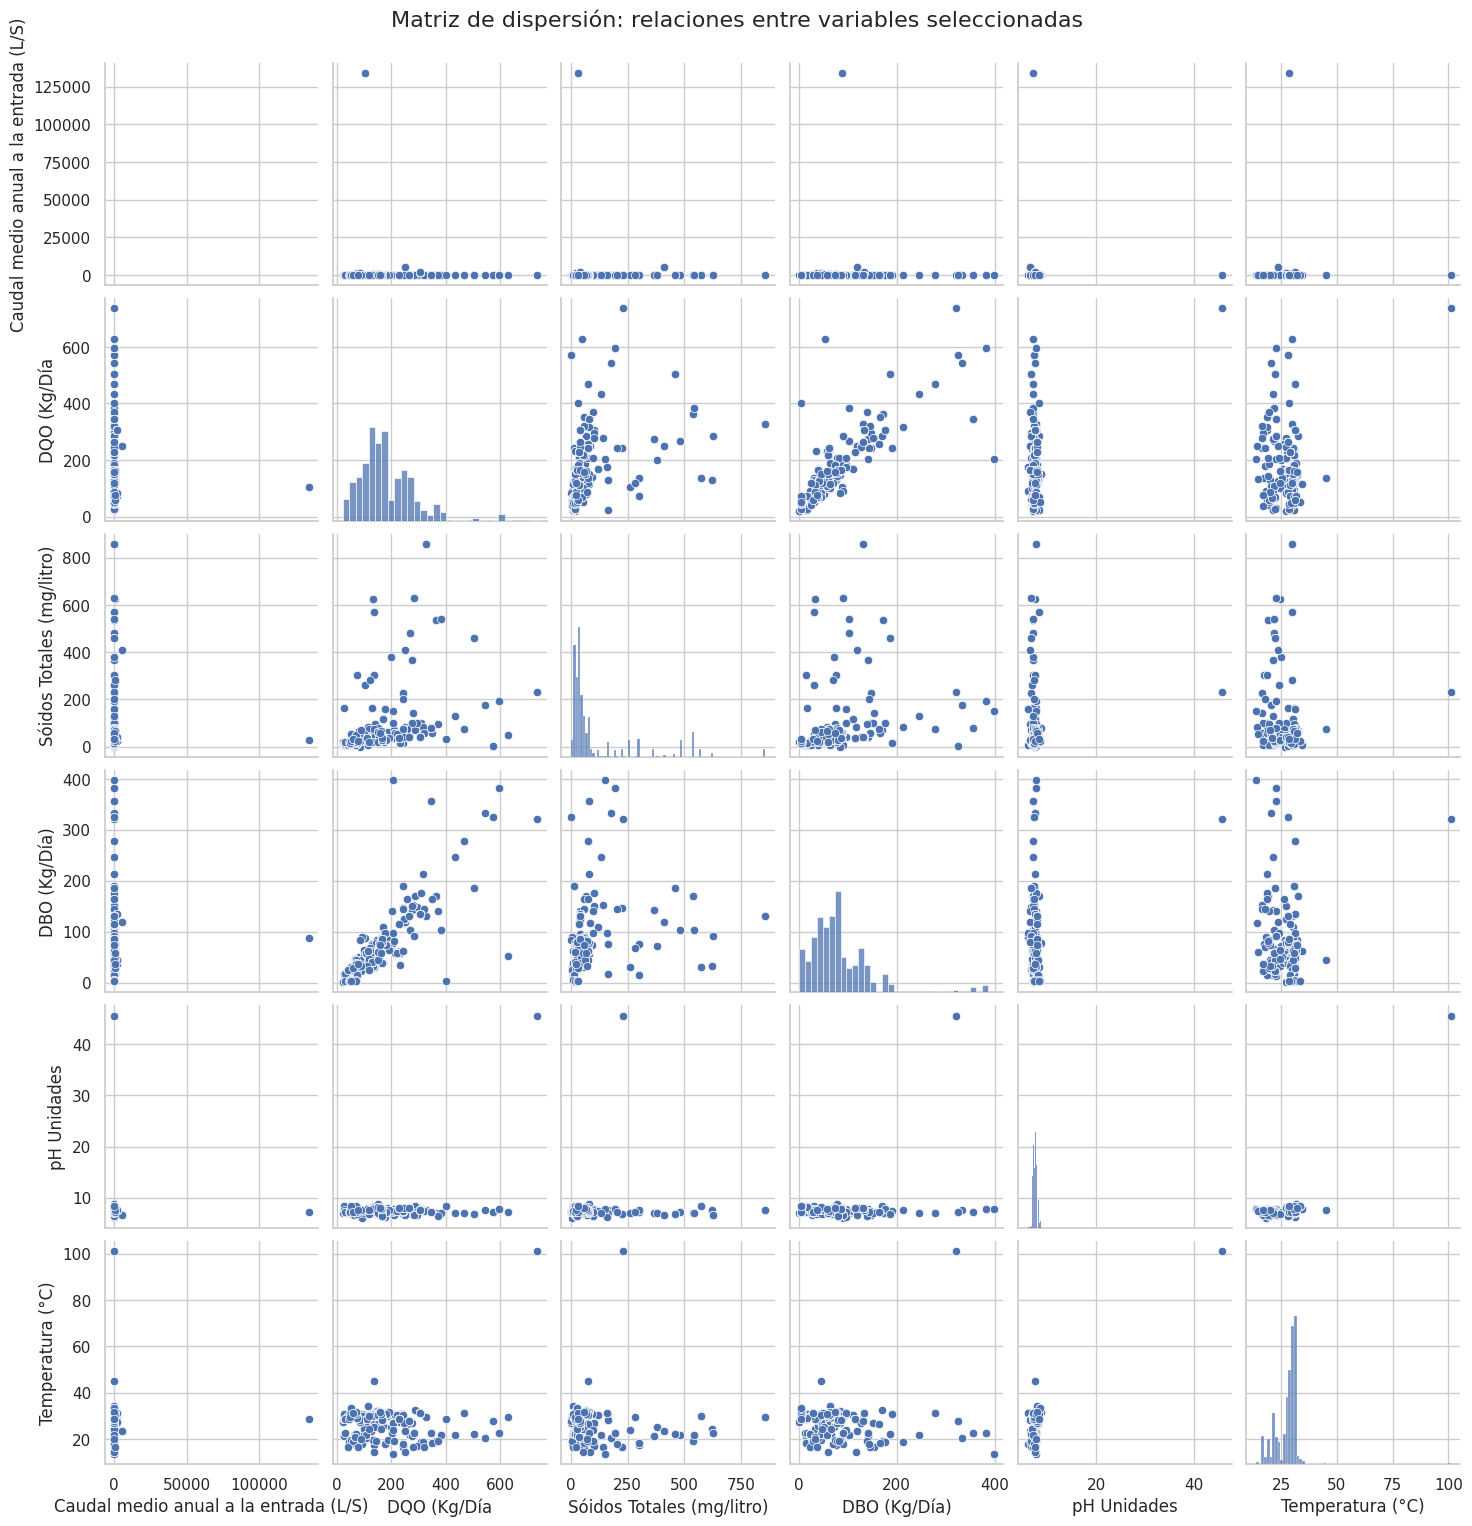

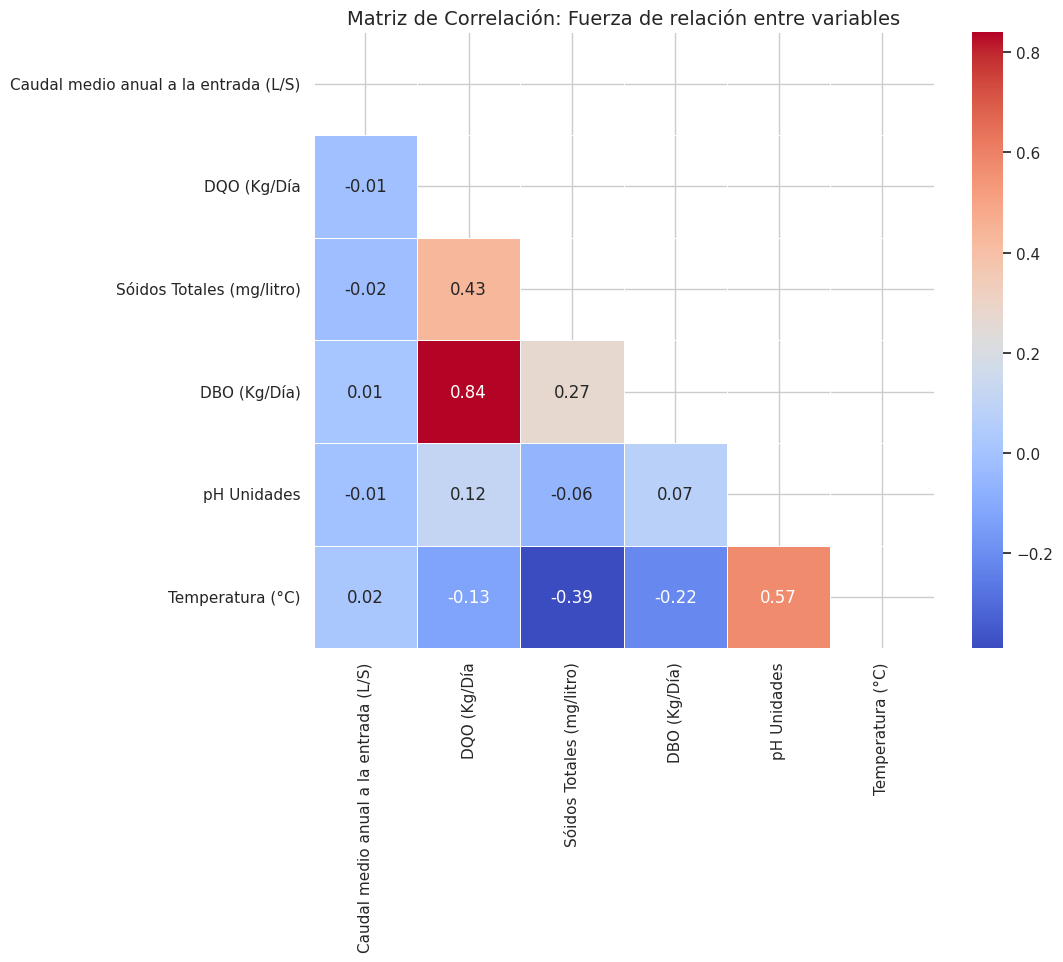

In [ ]:
# Seleccionar las columnas numéricas relevantes para PCA
numerical_cols = ['Caudal medio anual a la entrada (L/S)', 'DQO (Kg/Día', 'Sóidos Totales (mg/litro)',
                             'DBO (Kg/Día)', 'pH Unidades', 'Temperatura (°C)']

# Crear un DataFrame para el PCA y pairplot
# y eliminando filas con NaN en cualquiera de las columnas seleccionadas
df_for_analysis = df_limpio[numerical_cols].dropna()

# Estandarización
scaler = StandardScaler()
X_std = scaler.fit_transform(df_for_analysis)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_std)

# Visualización con pairplot
sns.pairplot(df_for_analysis, diag_kind='hist', corner=False)
plt.suptitle('Matriz de dispersión: relaciones entre variables seleccionadas', fontsize=16, y=1.02)
plt.show()

# Matriz de correlación de Pearson
corr_matrix = df_for_analysis.corr()

# Visualización
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Ver solo la mitad inferior

sns.heatmap(corr_matrix,
            annot=True,          # Muestra los valores numéricos
            fmt=".2f",           # Dos decimales
            cmap='coolwarm',     # Escala de colores (rojo positivo, azul negativo)
            mask=mask,           # Evita información redundante
            linewidths=0.5)

plt.title('Matriz de Correlación: Fuerza de relación entre variables', fontsize=14)
plt.show()

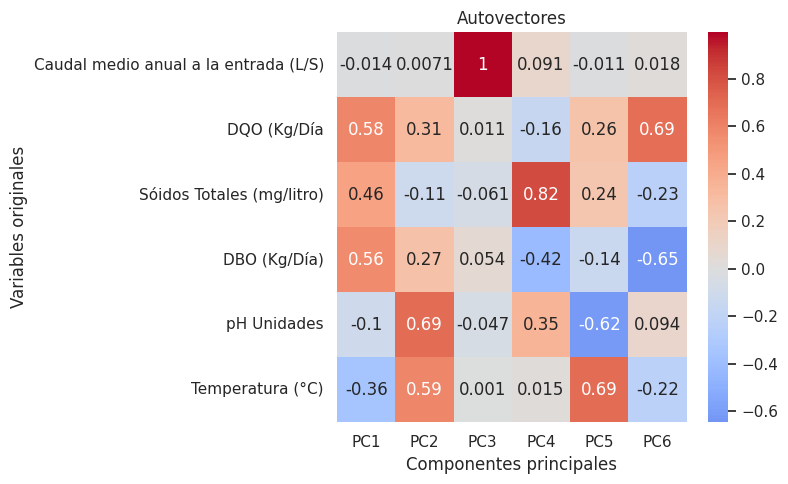

Ecuaciones de los componentes principales:

PC1 = -0.014·'Caudal medio anual a la entrada (L/S)' + 0.582·'DQO (Kg/Día' + 0.455·'Sóidos Totales (mg/litro)' + 0.563·'DBO (Kg/Día)' + -0.103·'pH Unidades' + -0.356·'Temperatura (°C)'
PC2 = 0.007·'Caudal medio anual a la entrada (L/S)' + 0.311·'DQO (Kg/Día' + -0.111·'Sóidos Totales (mg/litro)' + 0.266·'DBO (Kg/Día)' + 0.688·'pH Unidades' + 0.588·'Temperatura (°C)'
PC3 = 0.996·'Caudal medio anual a la entrada (L/S)' + 0.011·'DQO (Kg/Día' + -0.061·'Sóidos Totales (mg/litro)' + 0.054·'DBO (Kg/Día)' + -0.047·'pH Unidades' + 0.001·'Temperatura (°C)'
PC4 = 0.091·'Caudal medio anual a la entrada (L/S)' + -0.162·'DQO (Kg/Día' + 0.817·'Sóidos Totales (mg/litro)' + -0.417·'DBO (Kg/Día)' + 0.353·'pH Unidades' + 0.015·'Temperatura (°C)'
PC5 = -0.011·'Caudal medio anual a la entrada (L/S)' + 0.261·'DQO (Kg/Día' + 0.237·'Sóidos Totales (mg/litro)' + -0.137·'DBO (Kg/Día)' + -0.617·'pH Unidades' + 0.69·'Temperatura (°C)'
PC6 = 0.018·'Caudal medio anual a la

In [ ]:
# Matriz de componentes
componentes = pd.DataFrame(pca.components_.T,
                           columns=[f'PC{i+1}' for i in range(pca.n_components_)],
                           index=df_for_analysis.columns)

# Visualización de autovectores
plt.figure(figsize=(8, 5))
sns.heatmap(componentes, annot=True, cmap='coolwarm', center=0)
plt.title('Autovectores')
plt.ylabel('Variables originales')
plt.xlabel('Componentes principales')
plt.tight_layout()
plt.show()

# Ecuaciones de los componentes principales con nombres reales
print("Ecuaciones de los componentes principales:\n")
for i, comp in enumerate(componentes.columns):
    pesos = pca.components_[i]
    ecuacion = " + ".join([f"{round(pesos[j], 3)}·'{df_for_analysis.columns[j]}'" for j in range(len(pesos))])
    print(f"{comp} = {ecuacion}")

Matriz resumen de varianza explicada:

  Componente  Autovalor    PVE  PVE acumulada
0        PC1      2.211  0.368          0.368
1        PC2      1.583  0.264          0.632
2        PC3      1.003  0.167          0.799
3        PC4      0.740  0.123          0.922
4        PC5      0.348  0.058          0.980
5        PC6      0.120  0.020          1.000


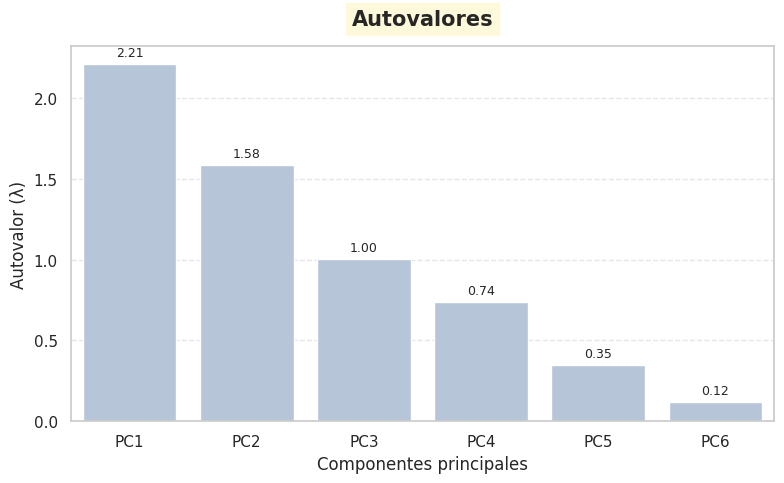

In [ ]:
# Varianza explicada
varianza = pca.explained_variance_
PVE = pca.explained_variance_ratio_
PVE_acum = np.cumsum(PVE)
componentes = [f'PC{i+1}' for i in range(len(PVE))]

# DataFrame para visualización
df_varianza = pd.DataFrame({
    'Componente': componentes,
    'Autovalor': varianza,
    'PVE': PVE,
    'PVE acumulada': PVE_acum
})

print("Matriz resumen de varianza explicada:\n")
print(df_varianza.round(3))

# --------------------------
# Gráfico 1: Autovalores
# --------------------------
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Componente', y='Autovalor', data=df_varianza, color='lightsteelblue')
for i, v in enumerate(df_varianza['Autovalor']):
    ax.text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=9)
plt.title("Autovalores", fontsize=15, fontweight="bold", backgroundcolor="#fff9db", pad=15)
plt.ylabel("Autovalor (λ)")
plt.xlabel("Componentes principales")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Escalamiento y transformación

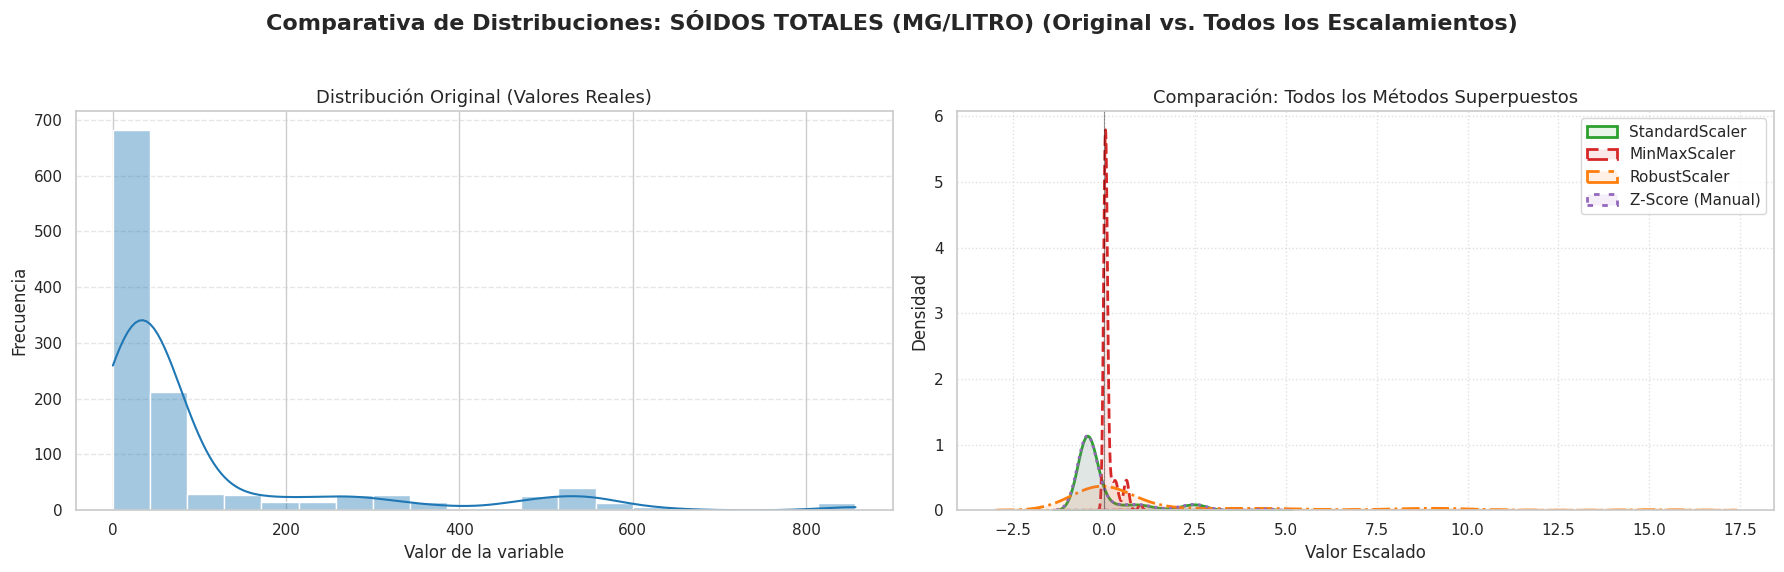

In [ ]:
# escalamiento
# Seleccionar variables
features = ['Caudal medio anual a la entrada (L/S)',
    'pH Unidades',
    'Temperatura (°C)',
    'DBO (Kg/Día)',
    'DQO (Kg/Día',
    'Sóidos Totales (mg/litro)'
]
data_subset = df_limpio[features]

# Diccionario de escalamientos
scalers = {
    'StandardScaler': StandardScaler().fit_transform(data_subset),
    'MinMaxScaler': MinMaxScaler().fit_transform(data_subset),
    'RobustScaler': RobustScaler().fit_transform(data_subset),
    'Z-Score (Manual)': stats.zscore(data_subset, nan_policy='omit')
}

indices = np.arange(len(df))

# Define 'variable' and 'col_idx' for plotting (e.g., 'ash')
variable = 'Sóidos Totales (mg/litro)'
col_idx = features.index(variable)

datos_originales = df[variable].values

import seaborn as sns
import matplotlib.pyplot as plt

# Figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'Comparativa de Distribuciones: {variable.upper()} (Original vs. Todos los Escalamientos)',
             fontsize=16, fontweight='bold')

# --- PANEL 1: DATOS ORIGINALES ---
sns.histplot(datos_originales, kde=True, color='tab:blue', ax=ax1, bins=20, alpha=0.4)
ax1.set_title('Distribución Original (Valores Reales)', fontsize=13)
ax1.set_xlabel('Valor de la variable')
ax1.set_ylabel('Frecuencia')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- PANEL 2: COMPARATIVA DE TODOS LOS ESCALAMIENTOS ---
# Definimos colores para diferenciar los métodos
colores = ['tab:green', 'tab:red', 'tab:orange', 'tab:purple']
estilos = ['-', '--', '-.', ':']

for i, (name, transformed_data) in enumerate(scalers.items()):
    # Extraer la columna 'variable' del método actual
    values_scaled = transformed_data[:, col_idx]

    # Graficamos la línea de densidad (KDE) para que no se amontonen tantas barras
    sns.kdeplot(values_scaled, ax=ax2, label=name, color=colores[i],
                linestyle=estilos[i], linewidth=2, fill=True, alpha=0.1)

ax2.set_title('Comparación: Todos los Métodos Superpuestos', fontsize=13)
ax2.set_xlabel('Valor Escalado')
ax2.set_ylabel('Densidad')
ax2.axvline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.4) # Eje central
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

comparando los métodos para cada una de las variables, se llegó a la conclusión qeu RobustScaler es el mejor para todas, entonces los datos usados de aquí en adelante serán los resultados del RobustScaler

In [ ]:
# Seleccionar las mismas variables utilizadas para el escalamiento
features = ['Caudal medio anual a la entrada (L/S)',
    'pH Unidades',
    'Temperatura (°C)',
    'DBO (Kg/Día)',
    'DQO (Kg/Día',
    'Sóidos Totales (mg/litro)'
]

# Crear una copia de df_limpio para trabajar
df_robust_scaled = df_limpio.copy()

# Inicializar y aplicar RobustScaler a las columnas seleccionadas
robust_scaler = RobustScaler()

# Asegurarse de que los valores NaN sean tratados correctamente antes del escalado
df_robust_scaled[features] = robust_scaler.fit_transform(df_robust_scaled[features])

print("--- Primeras filas del DataFrame con las variables escaladas por RobustScaler ---")
display(df_robust_scaled[features].head())

--- Primeras filas del DataFrame con las variables escaladas por RobustScaler ---


,Caudal medio anual a la entrada (L/S),pH Unidades,Temperatura (°C),DBO (Kg/Día),DQO (Kg/Día,Sóidos Totales (mg/litro)
0,NaN,NaN,NaN,NaN,NaN,NaN
1,-0.228549,-0.527070,-1.131774,0.581007,0.863827,8.162866
2,-0.168643,-0.797771,-1.551129,1.657182,1.602076,9.197169
3,-0.308060,-0.574841,-1.857581,0.159757,-0.133189,4.856791
4,-0.425692,-0.893312,-0.809194,-0.568290,-0.376735,4.062594


Una vez los datos están escaldos con robust scale (df_robust_sacaled) se procede a comparar diferentes transformaciones para ver cuál es la mejor para cada una de las variables

In [ ]:
# Lista de variables a transformar (las mismas que se usaron para RobustScaler)
features = [
    'Caudal medio anual a la entrada (L/S)',
    'pH Unidades',
    'Temperatura (°C)',
    'DBO (Kg/Día)',
    'DQO (Kg/Día',
    'Sóidos Totales (mg/litro)'
]

data_escalada = df_robust_scaled[features]


# Asegurar que todos los valores sean positivos para log y boxcox
x_positive = data_escalada.copy()
for col in features:
    min_val = x_positive[col].min(skipna=True)
    if pd.notna(min_val) and min_val <= 0:
        x_positive[col] = x_positive[col] + abs(min_val) + 0.1

# Diccionario para almacenar los DataFrames transformados
transfor = {}

# Aplicar Logarítmica
transfor['logaritmica'] = np.log(x_positive)

# Aplicar Logarítmica Reflejada
# Esta transformación es específica para cada columna
transfor_reflejada_dfs = []
for col in features:
    col_data = x_positive[col].dropna()
    if not col_data.empty:
        max_val = col_data.max()
        reflected_data = max_val + 1 - col_data

        if (reflected_data > 0).all():
            transfor_reflejada_dfs.append(pd.Series(np.log(reflected_data), index=col_data.index, name=col))
        else:

            transfor_reflejada_dfs.append(pd.Series(np.nan, index=x_positive.index, name=col))
    else:
        transfor_reflejada_dfs.append(pd.Series(np.nan, index=x_positive.index, name=col))
if transfor_reflejada_dfs:
    transfor['logaritmica reflejada'] = pd.concat(transfor_reflejada_dfs, axis=1)
else:
    transfor['logaritmica reflejada'] = pd.DataFrame(index=x_positive.index, columns=features)


# Aplicar Box-Cox (requiere datos estrictamente positivos y 1-dimensionales)
boxcox_transformed_dfs = []
for col in features:
    col_data = x_positive[col].dropna()

    if len(col_data) > 0 and (col_data > 0).all() and col_data.std() > 0:
        try:
            transformed, _ = boxcox(col_data)
            boxcox_transformed_dfs.append(pd.Series(transformed, index=col_data.index, name=col))
        except ValueError:

            boxcox_transformed_dfs.append(pd.Series(np.nan, index=x_positive.index, name=col))
    else:
        boxcox_transformed_dfs.append(pd.Series(np.nan, index=x_positive.index, name=col))

if boxcox_transformed_dfs:
    transfor['box-cox'] = pd.concat(boxcox_transformed_dfs, axis=1)
else:
    transfor['box-cox'] = pd.DataFrame(index=x_positive.index, columns=features)

# Aplicar Raíz Cuadrada
transfor['raiz cuadrada'] = np.sqrt(x_positive)

# Aplicar Raíz Cúbica
transfor['raiz cúbica'] = np.cbrt(x_positive)


In [ ]:
# Lista de variables a analizar
features = [
    'Caudal medio anual a la entrada (L/S)',
    'pH Unidades',
    'Temperatura (°C)',
    'DBO (Kg/Día)',
    'DQO (Kg/Día',
    'Sóidos Totales (mg/litro)'
]

results = []

for feature in features:
    # 1. Datos originales (escalados con RobustScaler)
    original_data = df_robust_scaled[feature].dropna()

    if original_data.empty:
        print(f"No hay datos válidos para la variable {feature}. Saltando.")
        continue

    # Registrar métricas de los datos originales
    results.append({
        'Variable': feature,
        'Transformación': 'Original (RobustScaler)',
        'Asimetría': skew(original_data),
        'Curtosis': kurtosis(original_data, fisher=True)
    })

    # 2. Iterar sobre el diccionario de transformaciones
    for trans_name, transformed_df in transfor.items():
        if feature in transformed_df.columns:
            transformed_data = transformed_df[feature].dropna()

            if not transformed_data.empty:
                # Calcular métricas para la transformación actual
                current_skew = skew(transformed_data)
                current_kurtosis = kurtosis(transformed_data, fisher=True)

                results.append({
                    'Variable': feature,
                    'Transformación': trans_name,
                    'Asimetría': current_skew,
                    'Curtosis': current_kurtosis
                })

# Crear y mostrar tabla resumen
results_df = pd.DataFrame(results)
print("\n--- Tabla Resumen de Calidad de la Distribución ---")
display(results_df)


--- Tabla Resumen de Calidad de la Distribución ---


,Variable,Transformación,Asimetría,Curtosis
0,Caudal medio anual a la entrada (L/S),Original (RobustScaler),32.650671,1077.815574
1,Caudal medio anual a la entrada (L/S),logaritmica,1.295379,2.524555
2,Caudal medio anual a la entrada (L/S),logaritmica reflejada,-33.290417,1106.501001
3,Caudal medio anual a la entrada (L/S),box-cox,0.068279,-0.531018
4,Caudal medio anual a la entrada (L/S),raiz cuadrada,15.765210,377.644344
5,Caudal medio anual a la entrada (L/S),raiz cúbica,6.433885,85.258455
6,pH Unidades,Original (RobustScaler),26.599183,813.509186
7,pH Unidades,logaritmica,-0.999175,12.606666
8,pH Unidades,logaritmica reflejada,-32.471659,1061.544754
9,pH Unidades,box-cox,0.297486,19.835041


la comparación de los diferentes métodos de transformación dejan ver que la mejor transformación para la base de datos y todas las variables termina siendo box-cox, entonces esta transformación se aplicará y luego se hará la detección de atipicos

In [ ]:
# Asumiendo que 'transfor' ya contiene el DataFrame con la transformación Box-Cox
# y que 'features' es la lista de columnas usadas para la transformación.

# Seleccionar el DataFrame con la transformación Box-Cox
if 'box-cox' in transfor and isinstance(transfor['box-cox'], pd.DataFrame):
    df_final_transformed = transfor['box-cox'][features].copy()
else:
    print("Error: No se encontró la transformación 'box-cox' o no es un DataFrame válido.")
    print("Asegúrate de que la celda anterior con las transformaciones se haya ejecutado correctamente.")
    df_final_transformed = pd.DataFrame(columns=features) # Crear un DataFrame vacío

print("--- Primeras filas del DataFrame con Box-Cox aplicado ---")
display(df_final_transformed.head())

--- Primeras filas del DataFrame con Box-Cox aplicado ---


,Caudal medio anual a la entrada (L/S),pH Unidades,Temperatura (°C),DBO (Kg/Día),DQO (Kg/Día,Sóidos Totales (mg/litro)
1,-1.196518,0.699953,0.397356,0.585107,0.775040,1.454643
2,-0.992491,0.536716,-0.008071,1.178273,1.205242,1.498498
3,-1.547903,0.672617,-0.325353,0.274558,-0.017240,1.247185
4,-2.411050,0.473696,0.693437,-0.514776,-0.286090,1.170207
5,-1.196518,0.699953,0.397356,0.585107,0.775040,1.454643


# Detección de atípicos y datos faltantes

In [ ]:
# Detección de atípicos
# features = ['Caudal medio anual a la entrada (L/S)', 'pH Unidades', 'Temperatura (°C)', 'DBO (Kg/Día)', 'DQO (Kg/Día', 'Sóidos Totales (mg/litro)']

outliers_report = []

for col in features: # Iterar sobre la lista 'features' original

    data = df_final_transformed[col].dropna()

    if data.empty:
        print(f"Advertencia: No hay datos válidos para detectar atípicos en la columna '{col}'. Saltando.")
        continue

    # Calcular Q1 (25%) y Q3 (75%)
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    # Definir límites (Estándar: 1.5 * IQR)
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Identificar atípicos
    outliers = data[(data < limite_inferior) | (data > limite_superior)]

    outliers_report.append({
        'Variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Límite Inf': limite_inferior,
        'Límite Sup': limite_superior,
        'Cant. Atípicos': len(outliers),
        '% Atípicos': (len(outliers) / len(data)) * 100
    })

# Mostrar resultados
df_outliers = pd.DataFrame(outliers_report)
print("--- Detección de Atípicos (Post-Transformación Box-Cox) ---")
display(df_outliers)

--- Detección de Atípicos (Post-Transformación Box-Cox) ---


,Variable,Q1,Q3,IQR,Límite Inf,Límite Sup,Cant. Atípicos,% Atípicos
0,Caudal medio anual a la entrada (L/S),-1.790365,0.206035,1.996400,-4.784964,3.200635,0,0.000000
1,pH Unidades,0.699953,1.171062,0.471109,-0.006710,1.877725,36,3.317972
2,Temperatura (°C),0.794504,1.646195,0.851691,-0.483033,2.923732,8,0.737327
3,DBO (Kg/Día),-0.308542,0.585107,0.893649,-1.649016,1.925581,27,2.454545
4,DQO (Kg/Día,-0.226395,0.647951,0.874346,-1.537914,1.959471,14,1.275046
5,Sóidos Totales (mg/litro),-0.646790,0.408513,1.055304,-2.229746,1.991469,5,0.459559


el porcentaje de datos atípicos es menor al 5%, entonces se dejarán

In [ ]:
# Aislar y ver atípicos
def identificar_atipicos(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    return df[(df[columna] < lim_inf) | (df[columna] > lim_sup)]

# Diccionario para guardar los dataframes de atípicos
todos_los_atipicos = {}

print("--- REPORTE DETALLADO DE ATÍPICOS POR VARIABLE ---")
print("-" * 50)

for var in features:
    # Llamar función para identificar los índices atípicos
    df_atipicos_var = identificar_atipicos(df_final_transformed, var)

    # Guardar en el diccionario
    todos_los_atipicos[var] = df_atipicos_var

    cant = len(df_atipicos_var)
    print(f"\nVARIABLE: {var}")
    print(f"Se encontraron {cant} registros atípicos.")

    if cant > 0:
        # Mostrar los datos ORIGINALES (del df_limpio) usando los índices de los atípicos
        columnas_ver = ['Empresa', 'Departamento', 'Municipio',
                        'Caudal medio anual a la entrada (L/S)', 'pH Unidades',
                        'Temperatura (°C)', 'DBO (Kg/Día)', 'DQO (Kg/Día', 'Sóidos Totales (mg/litro)']

        # Asegurar que solo se muestra si hay atípicos que mostrar y las columnas existen
        if not df_atipicos_var.empty:
            display(df_limpio.loc[df_atipicos_var.index, columnas_ver].head(10)) # Mostrar los primeros 10
        else:
            print("No outliers to display (after filtering).")
    else:
        print("Distribución limpia: No se detectaron anomalías matemáticas.")

    print("-" * 50)

--- REPORTE DETALLADO DE ATÍPICOS POR VARIABLE ---
--------------------------------------------------

VARIABLE: Caudal medio anual a la entrada (L/S)
Se encontraron 0 registros atípicos.
Distribución limpia: No se detectaron anomalías matemáticas.
--------------------------------------------------

VARIABLE: pH Unidades
Se encontraron 36 registros atípicos.


,Empresa,Departamento,Municipio,Caudal medio anual a la entrada (L/S),pH Unidades,Temperatura (°C),DBO (Kg/Día),DQO (Kg/Día,Sóidos Totales (mg/litro)
375,DIRECCIÓN DE SERVICIOS PÚBLICOS MUNICIPIO DE G...,CUNDINAMARCA,GUAYABETAL,1.060,6.000,18.000,90.00,90.000,5.000
471,EMPRESA DE SERVICIOS PUBLICOS DOMICILIARIOS DE...,ANTIOQUIA,GUARNE,29.883,45.670,101.000,321.00,736.100,231.000
487,EMPRESA MUNICIPAL DE SERVICIOS PUBLICOS DE PIE...,CAUCA,PIENDAMO,10.560,6.370,19.320,140.00,371.000,96.700
497,EMPRESA REGIONAL DE AGUAS DEL TEQUENDAMA S.A. ...,CUNDINAMARCA,ANAPOIMA,1.260,6.145,31.300,97.05,176.500,161.000
501,EMPRESA REGIONAL DE AGUAS DEL TEQUENDAMA S.A. ...,CUNDINAMARCA,LA MESA,1.260,6.145,31.300,97.05,176.500,161.000
503,EMPRESAS MUNICIPALES DE CALI E.I.C.E E.S.P,VALLE,CALI,5706.000,6.537,23.492,119.50,249.667,410.833
505,EMPRESAS MUNICIPALES DE CALI E.I.C.E E.S.P,VALLE,YUMBO,5706.000,6.537,23.492,119.50,249.667,410.833
922,SOCIEDAD DE ACUEDUCTOS Y ALCANTARILLADOS DEL V...,VALLE,ALCALA,26.990,6.400,28.200,80.00,165.000,27.000
927,SOCIEDAD DE ACUEDUCTOS Y ALCANTARILLADOS DEL V...,VALLE,ANDALUCIA,26.990,6.400,28.200,80.00,165.000,27.000
932,SOCIEDAD DE ACUEDUCTOS Y ALCANTARILLADOS DEL V...,VALLE,ARGELIA,26.990,6.400,28.200,80.00,165.000,27.000


--------------------------------------------------

VARIABLE: Temperatura (°C)
Se encontraron 8 registros atípicos.


,Empresa,Departamento,Municipio,Caudal medio anual a la entrada (L/S),pH Unidades,Temperatura (°C),DBO (Kg/Día),DQO (Kg/Día,Sóidos Totales (mg/litro)
438,EMPRESA DE SERVICIOS PUBLICOS DE CAJICA S.A. ...,CUNDINAMARCA,CAJICA,66.434,7.260,16.320,153.000,278.500,140.250
471,EMPRESA DE SERVICIOS PUBLICOS DOMICILIARIOS DE...,ANTIOQUIA,GUARNE,29.883,45.670,101.000,321.000,736.100,231.000
474,EMPRESA DE SERVICIOS PUBLICOS DOMICILIARIOS DE...,NARIÑO,TUQUERRES,1.460,7.670,13.670,398.000,205.000,150.000
475,EMPRESA DE SERVICIOS PUBLICOS DOMICILIARIOS DE...,NARIÑO,TUQUERRES,2.450,7.490,14.290,117.000,249.000,84.000
514,EMPRESAS PUBLICAS DE MONTERREY S.A. E.S.P.,CASANARE,MONTERREY,37.692,7.417,14.425,59.608,134.267,52.333
590,JUNTA MUNICIPAL DE SERVICIOS PUBLICOS DEL MUNI...,BOYACA,PAUNA,6.000,7.500,45.000,45.000,135.000,75.000
633,SISTEMAS PUBLICOS S.A. E.S.P.,ANTIOQUIA,NECOCLI,NaN,7.900,46.000,75.000,96.000,15.340
635,SISTEMAS PUBLICOS S.A. E.S.P.,ANTIOQUIA,SAN PEDRO DE URABA,NaN,7.900,46.000,75.000,96.000,15.340


--------------------------------------------------

VARIABLE: DBO (Kg/Día)
Se encontraron 27 registros atípicos.


...

--------------------------------------------------

VARIABLE: DQO (Kg/Día
Se encontraron 14 registros atípicos.


,Empresa,Departamento,Municipio,Caudal medio anual a la entrada (L/S),pH Unidades,Temperatura (°C),DBO (Kg/Día),DQO (Kg/Día,Sóidos Totales (mg/litro)
236,AGUAS Y AMBIENTE LA FONTANA DEL LLANO SAS ESP,META,VILLAVICENCIO,0.157,7.06,27.30,0.965,20.000,20.000
444,EMPRESA DE SERVICIOS PUBLICOS DE TAME CARIBAB...,ARAUCA,TAME,79.880,7.12,29.66,53.100,627.450,50.650
471,EMPRESA DE SERVICIOS PUBLICOS DOMICILIARIOS DE...,ANTIOQUIA,GUARNE,29.883,45.67,101.00,321.000,736.100,231.000
517,EMPRESAS PÚBLICAS DE MEDELLIN E.S.P.,ANTIOQUIA,BARBOSA,101.625,7.76,22.50,381.809,595.064,193.155
521,EMPRESAS PÚBLICAS DE MEDELLIN E.S.P.,ANTIOQUIA,BELLO,101.625,7.76,22.50,381.809,595.064,193.155
525,EMPRESAS PÚBLICAS DE MEDELLIN E.S.P.,ANTIOQUIA,CALDAS,101.625,7.76,22.50,381.809,595.064,193.155
529,EMPRESAS PÚBLICAS DE MEDELLIN E.S.P.,ANTIOQUIA,COPACABANA,101.625,7.76,22.50,381.809,595.064,193.155
533,EMPRESAS PÚBLICAS DE MEDELLIN E.S.P.,ANTIOQUIA,ENVIGADO,101.625,7.76,22.50,381.809,595.064,193.155
537,EMPRESAS PÚBLICAS DE MEDELLIN E.S.P.,ANTIOQUIA,GIRARDOTA,101.625,7.76,22.50,381.809,595.064,193.155
541,EMPRESAS PÚBLICAS DE MEDELLIN E.S.P.,ANTIOQUIA,ITAGUI,101.625,7.76,22.50,381.809,595.064,193.155


--------------------------------------------------

VARIABLE: Sóidos Totales (mg/litro)
Se encontraron 5 registros atípicos.


,Empresa,Departamento,Municipio,Caudal medio anual a la entrada (L/S),pH Unidades,Temperatura (°C),DBO (Kg/Día),DQO (Kg/Día,Sóidos Totales (mg/litro)
375,DIRECCIÓN DE SERVICIOS PÚBLICOS MUNICIPIO DE G...,CUNDINAMARCA,GUAYABETAL,1.06,6.00,18.00,90.0,90.0,5.00
383,EMPRESA DE ACUEDUCTO Y ALCANTARILLADO DE SANTA...,CUNDINAMARCA,SOACHA,11.25,7.35,19.00,30.0,76.0,5.00
386,EMPRESA DE ACUEDUCTO,CAUCA,CORINTO,53.79,7.44,26.72,83.0,83.0,0.10
498,EMPRESA REGIONAL DE AGUAS DEL TEQUENDAMA S.A. ...,CUNDINAMARCA,ANAPOIMA,5.91,7.25,27.90,325.5,573.0,1.05
502,EMPRESA REGIONAL DE AGUAS DEL TEQUENDAMA S.A. ...,CUNDINAMARCA,LA MESA,5.91,7.25,27.90,325.5,573.0,1.05


--------------------------------------------------


Esto fue importante porque permite ver los atípicos a qué se pueden relacionar y en casos puntuales evaluar la integridad de los datos, como un pH de 45 que no es posible y condiciones específicas de las plantas, como temperaturas de 101 °C que es muy poco probable y pH ácido que conrresponde a aguas industriales. Esto permite también observar que algunos datos son exactamente iguales y solo cambia el municipio, lo que hace dudar de la integridad de la base de datos. Entonces ahora el paso siguiente es eliminar duplicados e imputar.

In [ ]:
# Faltantes por columna
faltantes = df_final_transformed.isnull().sum()
porcentaje = (faltantes / len(df_final_transformed)) * 100

resumen_faltantes = pd.DataFrame({
    'Cant. Faltantes': faltantes,
    'Porcentaje (%)': porcentaje
})

resumen_faltantes = resumen_faltantes.sort_values(by='Porcentaje (%)', ascending=False)
print("--- Reporte de Datos Faltantes por Variable ---")
display(resumen_faltantes.style.format({'Porcentaje (%)': '{:.2f}%'}))

--- Reporte de Datos Faltantes por Variable ---


,Cant. Faltantes,Porcentaje (%)
pH Unidades,43,3.81%
Temperatura (°C),43,3.81%
Sóidos Totales (mg/litro),40,3.55%
DQO (Kg/Día,30,2.66%
DBO (Kg/Día),28,2.48%
Caudal medio anual a la entrada (L/S),16,1.42%


In [ ]:
# Faltantes por fila
nulos_por_fila = df_final_transformed.isnull().sum(axis=1)

# Calcular el porcentaje de nulos por fila respecto al total de columnas
total_columnas = len(df_final_transformed.columns)
porcentaje_nulos_fila = (nulos_por_fila / total_columnas) * 100

# Crear un DataFrame de diagnóstico de filas
df_diagnostico_filas = df_final_transformed.copy()

# Añadir las columnas de identificación del df_limpio a df_diagnostico_filas
# Asegurarse de que las filas existan en ambos DataFrames antes de la unión
common_index = df_diagnostico_filas.index.intersection(df_limpio.index)
df_diagnostico_filas = df_diagnostico_filas.loc[common_index].copy()
df_diagnostico_filas[['Empresa', 'Departamento', 'Municipio']] = df_limpio.loc[common_index, ['Empresa', 'Departamento', 'Municipio']]

df_diagnostico_filas['Cant_Nulos'] = nulos_por_fila.loc[common_index]
df_diagnostico_filas['Porcentaje_Nulos'] = porcentaje_nulos_fila.loc[common_index]

# ¿Cuáles tienen más del 25% de sus datos faltantes?
umbral = 25
filas_criticas = df_diagnostico_filas[df_diagnostico_filas['Porcentaje_Nulos'] > umbral]

# Ordenar por las más vacías
filas_criticas = filas_criticas.sort_values(by='Porcentaje_Nulos', ascending=False)

print(f"--- Observaciones con más del {umbral}% de datos faltantes ---")
print(f"Se encontraron {len(filas_criticas)} filas en estado crítico.")
display(filas_criticas[['Empresa', 'Departamento', 'Municipio', 'Cant_Nulos', 'Porcentaje_Nulos']].head(10)) # Mostrar 10 de los registros con información faltante


--- Observaciones con más del 25% de datos faltantes ---
Se encontraron 45 filas en estado crítico.


,Empresa,Departamento,Municipio,Cant_Nulos,Porcentaje_Nulos
170,ADMINISTRACION PUBLICA COOPERATIVA EMPRESA DE ...,MAGDALENA,EL PIÑON,5,83.333333
171,ADMINISTRACION PUBLICA COOPERATIVA EMPRESA DE ...,MAGDALENA,EL PIÑON,5,83.333333
172,ADMINISTRACION PUBLICA COOPERATIVA EMPRESA DE ...,MAGDALENA,SALAMINA,5,83.333333
173,ADMINISTRACION PUBLICA COOPERATIVA EMPRESA DE ...,MAGDALENA,SALAMINA,5,83.333333
174,ADMINISTRACION PUBLICA COOPERATIVA EMPRESA SOL...,BOYACA,SAN MIGUEL DE SEMA,5,83.333333
248,AQUALIA LATINOAMERICA S.A. E.S.P.,CORDOBA,CERETE,5,83.333333
259,AQUALIA LATINOAMERICA S.A. E.S.P.,CORDOBA,CHIMA,5,83.333333
270,AQUALIA LATINOAMERICA S.A. E.S.P.,CORDOBA,CIENAGA DE ORO,5,83.333333
281,AQUALIA LATINOAMERICA S.A. E.S.P.,CORDOBA,LORICA,5,83.333333
292,AQUALIA LATINOAMERICA S.A. E.S.P.,CORDOBA,MOMIL,5,83.333333


las observaciones con más del 25% de datos faltantes se eliminarán porque la imputación de datos en estos casos ya sería muy riesgosa debido a que cada planta de tratamiento es un caso particular que en algunos casos puede llegar a ser aislado.

In [ ]:
# Obtener los índices de las filas críticas
indices_a_eliminar = filas_criticas.index

print(f"Número de filas antes de eliminar: {len(df_limpio)}")

# Eliminar las filas de df_limpio
df_limpio_cleaned = df_limpio.drop(indices_a_eliminar)

# Eliminar las filas de df_robust_scaled para mantener la consistencia
df_robust_scaled_cleaned = df_robust_scaled.drop(indices_a_eliminar)

# Eliminar las filas de df_final_transformed para mantener la consistencia
df_final_transformed_cleaned = df_final_transformed.drop(indices_a_eliminar)

print(f"Número de filas después de eliminar: {len(df_limpio_cleaned)}")
print(f"Filas eliminadas: {len(indices_a_eliminar)}")

print("\n--- Shapes de los DataFrames después de la limpieza ---")
print(f"df_limpio_cleaned shape: {df_limpio_cleaned.shape}")
print(f"df_robust_scaled_cleaned shape: {df_robust_scaled_cleaned.shape}")
print(f"df_final_transformed_cleaned shape: {df_final_transformed_cleaned.shape}")


Número de filas antes de eliminar: 1152
Número de filas después de eliminar: 1107
Filas eliminadas: 45

--- Shapes de los DataFrames después de la limpieza ---
df_limpio_cleaned shape: (1107, 12)
df_robust_scaled_cleaned shape: (1107, 12)
df_final_transformed_cleaned shape: (1083, 6)


In [ ]:
# Identificación de duplicados
print(df_limpio[df_limpio.duplicated()])
print('total de duplicados:', df_limpio.duplicated().sum())
print()
df_limpio.drop_duplicates(inplace=True)


Empty DataFrame
Columns: [Empresa, Departamento, Municipio, Número único de identificación del sistema de tratamiento (NUPTAR), Caudal medio anual a la entrada (L/S), Caudal medio anual a la salida (LTS/SG), pH Unidades, Temperatura (°C), Sóidos Totales (mg/litro), DBO (Kg/Día), DQO (Kg/Día, Fecha de cargue]
Index: []
total de duplicados: 0



Se observa que no hay duplicados, lo que es un buen indicio por lo que se describía anteriormente de las condiciones operativas de las plantas. Para la imputación de datos se usa KNN porque las PTAR suelen compartir características por región o por piso térmico. KNN captura esas "vecindades" mejor que una fórmula global de regresión.

# Imputación de datos

In [ ]:
# Imputación con KNN
# Columnas de importancia
features = [
    'Caudal medio anual a la entrada (L/S)',
    'pH Unidades',
    'Temperatura (°C)',
    'DBO (Kg/Día)',
    'DQO (Kg/Día',
    'Sóidos Totales (mg/litro)'
]

# Usar el DataFrame ya limpio y transformado que tiene los NaN (df_final_transformed_cleaned)
data_to_impute = df_final_transformed_cleaned[features].copy()

# Imputación con KNN
imputer = KNNImputer(n_neighbors=3)
data_imputed_array = imputer.fit_transform(data_to_impute)

# Convertir el resultado de nuevo a un DataFrame con los nombres de las columnas
df_final_imputed = pd.DataFrame(data_imputed_array,
                                columns=features,
                                index=df_final_transformed_cleaned.index)

# Reemplazar las columnas originales en df_final_transformed_cleaned con las imputadas
df_final_transformed_cleaned[features] = df_final_imputed

# -------- Verificación --------
print("Valores faltantes antes de imputar:")
print(data_to_impute.isnull().sum())

print("\nValores faltantes después de imputar:")
print(df_final_transformed_cleaned[features].isnull().sum())

print("\n--- Primeras filas del DataFrame con datos imputados ---")
display(df_final_transformed_cleaned[features].head())


Valores faltantes antes de imputar:
Caudal medio anual a la entrada (L/S)    5
pH Unidades                              0
Temperatura (°C)                         0
DBO (Kg/Día)                             0
DQO (Kg/Día                              2
Sóidos Totales (mg/litro)                7
dtype: int64

Valores faltantes después de imputar:
Caudal medio anual a la entrada (L/S)    0
pH Unidades                              0
Temperatura (°C)                         0
DBO (Kg/Día)                             0
DQO (Kg/Día                              0
Sóidos Totales (mg/litro)                0
dtype: int64

--- Primeras filas del DataFrame con datos imputados ---


,Caudal medio anual a la entrada (L/S),pH Unidades,Temperatura (°C),DBO (Kg/Día),DQO (Kg/Día,Sóidos Totales (mg/litro)
1,-1.196518,0.699953,0.397356,0.585107,0.775040,1.454643
2,-0.992491,0.536716,-0.008071,1.178273,1.205242,1.498498
3,-1.547903,0.672617,-0.325353,0.274558,-0.017240,1.247185
4,-2.411050,0.473696,0.693437,-0.514776,-0.286090,1.170207
6,-1.978361,1.080798,1.499909,0.846063,1.055466,1.664918


# Análisis multivariado con datos preprocesados

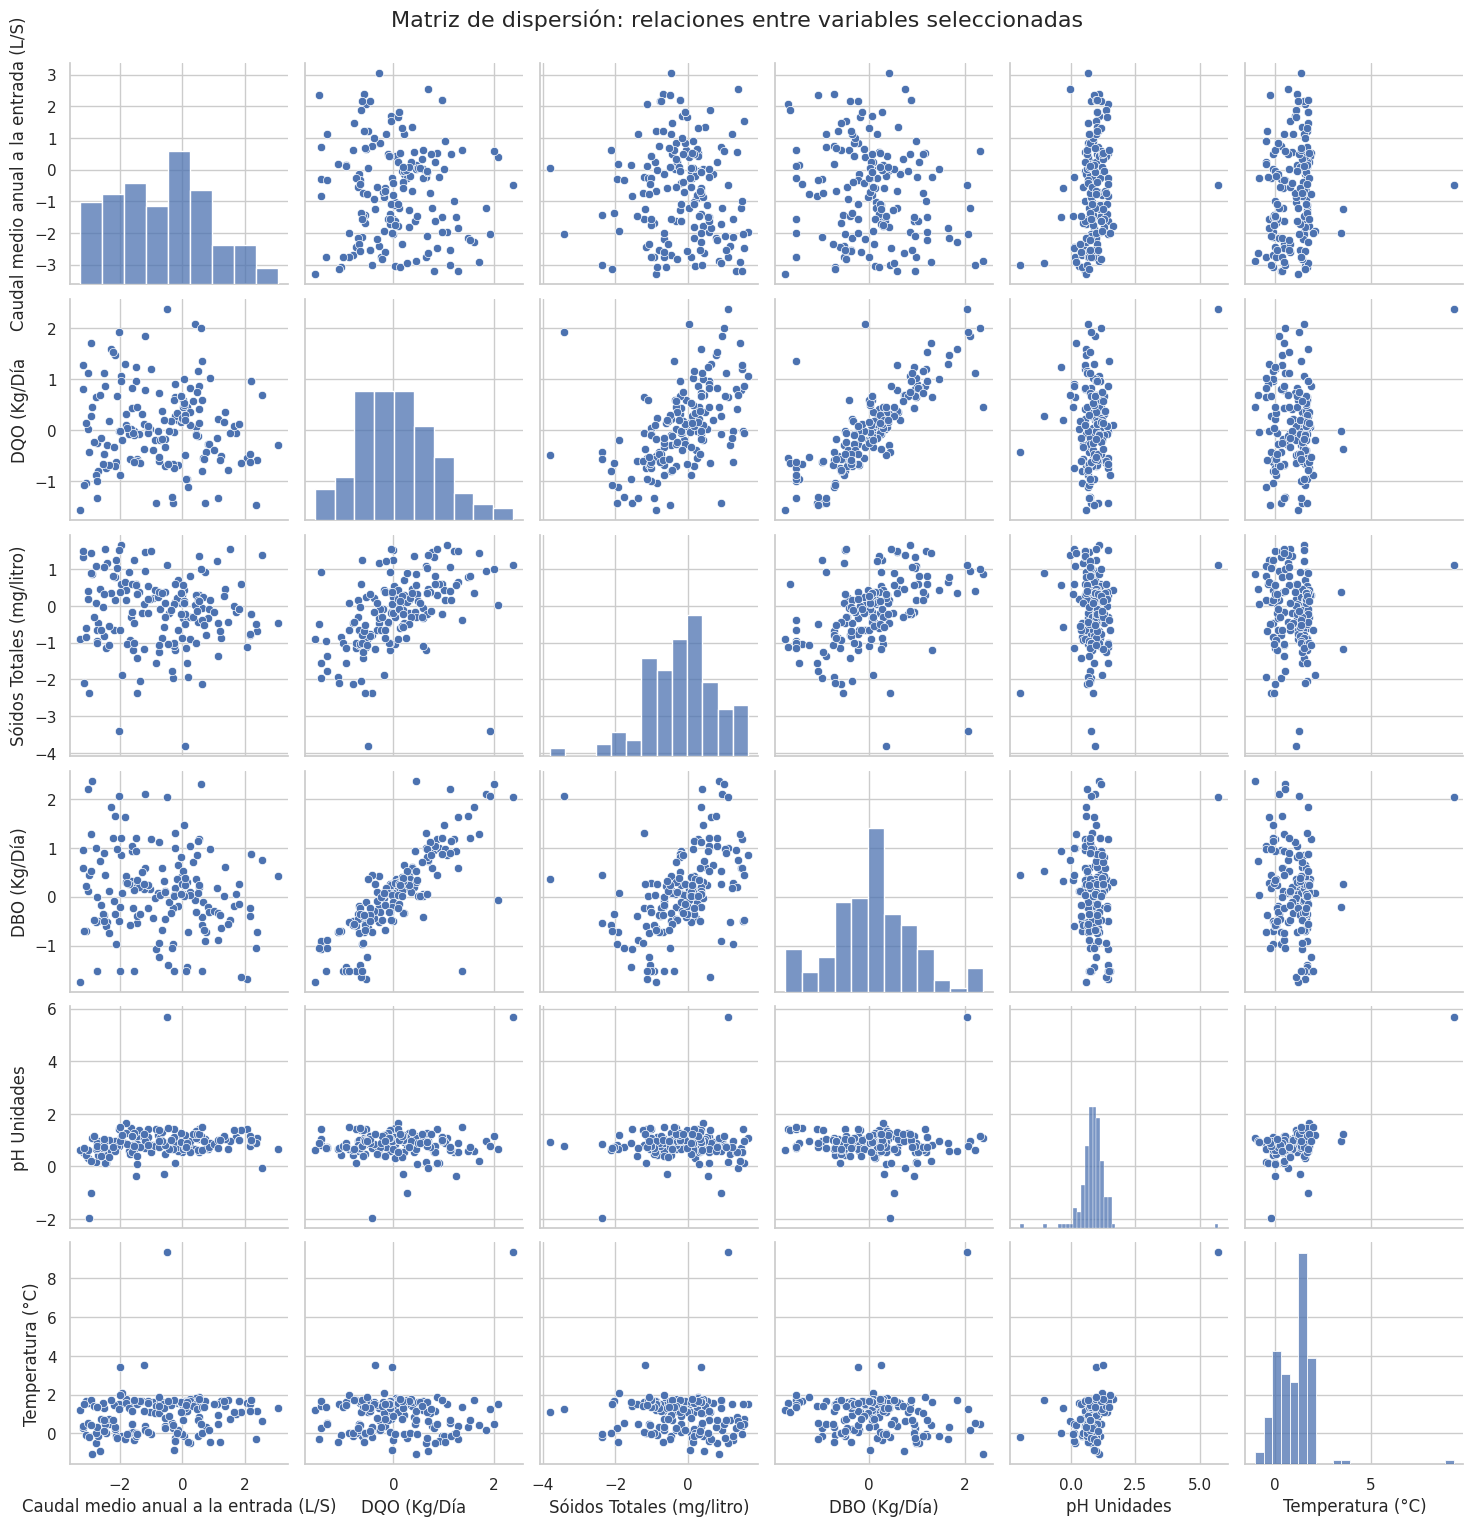

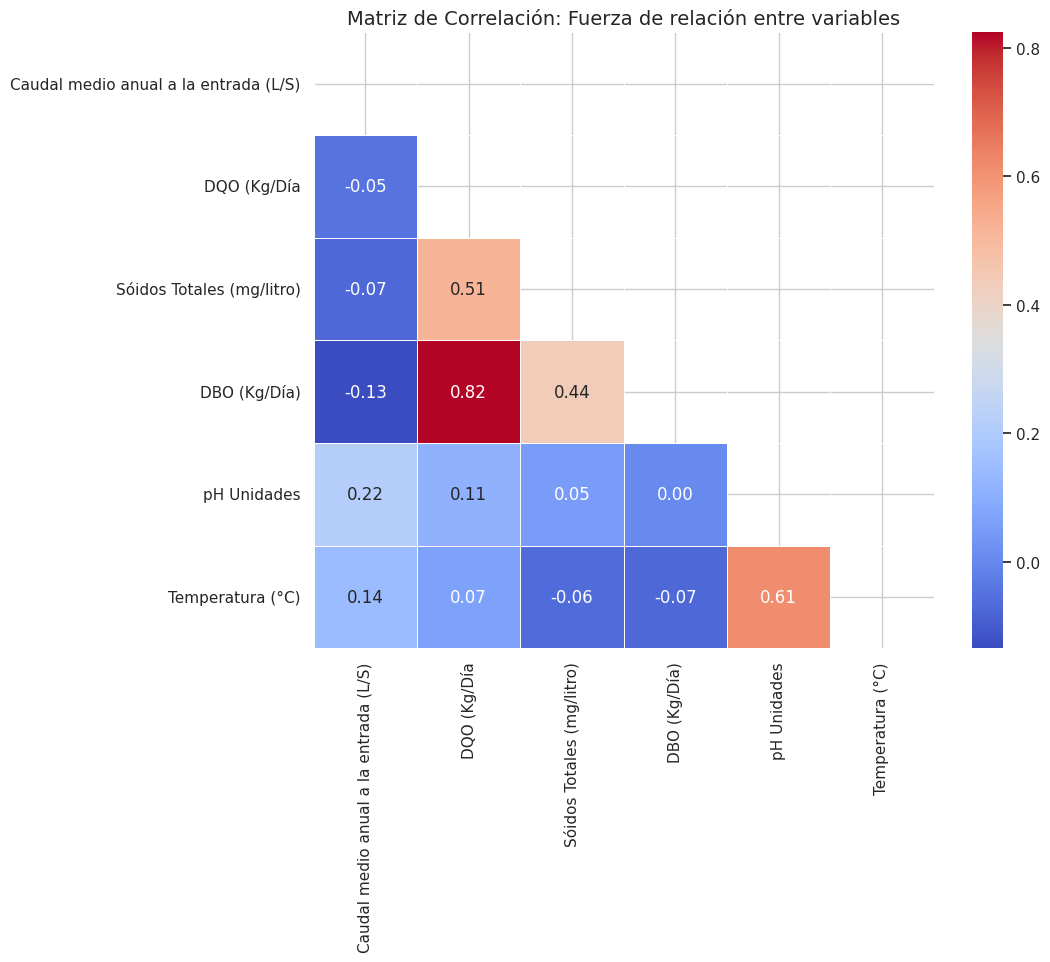

Varianza explicada por los componentes del PCA: [0.40691756 0.26398533 0.19419524 0.08885459 0.02878106 0.01726622]


In [ ]:
# Seleccionar las columnas numéricas relevantes para PCA
numerical_cols = ['Caudal medio anual a la entrada (L/S)', 'DQO (Kg/Día', 'Sóidos Totales (mg/litro)',
                             'DBO (Kg/Día)', 'pH Unidades', 'Temperatura (°C)']

df_for_analysis = df_final_transformed_cleaned[numerical_cols].dropna()

# PCA
pca = PCA()
X_pca = pca.fit_transform(df_for_analysis)

# Visualización con pairplot
sns.pairplot(df_for_analysis, diag_kind='hist', corner=False)
plt.suptitle('Matriz de dispersión: relaciones entre variables seleccionadas', fontsize=16, y=1.02)
plt.show()

# Matriz de correlación de Pearson
corr_matrix = df_for_analysis.corr()

# Visualización
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Ver solo la mitad inferior

sns.heatmap(corr_matrix,
            annot=True,          # Muestra los valores numéricos
            fmt=".2f",           # Dos decimales
            cmap='coolwarm',     # Escala de colores (rojo positivo, azul negativo)
            mask=mask,           # Evita información redundante
            linewidths=0.5)

plt.title('Matriz de Correlación: Fuerza de relación entre variables', fontsize=14)
plt.show()


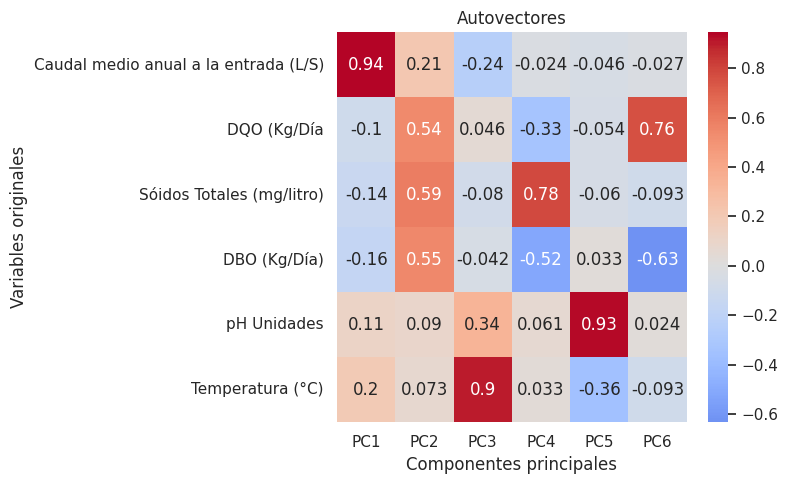

Ecuaciones de los componentes principales:

PC1 = 0.945·'Caudal medio anual a la entrada (L/S)' + -0.1·'DQO (Kg/Día' + -0.139·'Sóidos Totales (mg/litro)' + -0.165·'DBO (Kg/Día)' + 0.114·'pH Unidades' + 0.195·'Temperatura (°C)'
PC2 = 0.213·'Caudal medio anual a la entrada (L/S)' + 0.541·'DQO (Kg/Día' + 0.589·'Sóidos Totales (mg/litro)' + 0.549·'DBO (Kg/Día)' + 0.09·'pH Unidades' + 0.073·'Temperatura (°C)'
PC3 = -0.242·'Caudal medio anual a la entrada (L/S)' + 0.046·'DQO (Kg/Día' + -0.08·'Sóidos Totales (mg/litro)' + -0.042·'DBO (Kg/Día)' + 0.339·'pH Unidades' + 0.903·'Temperatura (°C)'
PC4 = -0.024·'Caudal medio anual a la entrada (L/S)' + -0.333·'DQO (Kg/Día' + 0.784·'Sóidos Totales (mg/litro)' + -0.518·'DBO (Kg/Día)' + 0.061·'pH Unidades' + 0.033·'Temperatura (°C)'
PC5 = -0.046·'Caudal medio anual a la entrada (L/S)' + -0.054·'DQO (Kg/Día' + -0.06·'Sóidos Totales (mg/litro)' + 0.033·'DBO (Kg/Día)' + 0.927·'pH Unidades' + -0.362·'Temperatura (°C)'
PC6 = -0.027·'Caudal medio anual a la 

In [ ]:
# Matriz de componentes
componentes = pd.DataFrame(pca.components_.T,
                           columns=[f'PC{i+1}' for i in range(pca.n_components_)],
                           index=df_for_analysis.columns)

# Visualización de autovectores
plt.figure(figsize=(8, 5))
sns.heatmap(componentes, annot=True, cmap='coolwarm', center=0)
plt.title('Autovectores')
plt.ylabel('Variables originales')
plt.xlabel('Componentes principales')
plt.tight_layout()
plt.show()

# Ecuaciones de los componentes principales
print("Ecuaciones de los componentes principales:\n")
for i, comp in enumerate(componentes.columns):
    pesos = pca.components_[i]
    ecuacion = " + ".join([f"{round(pesos[j], 3)}·'{df_for_analysis.columns[j]}'" for j in range(len(pesos))])
    print(f"{comp} = {ecuacion}")

Matriz resumen de varianza explicada:

  Componente  Autovalor    PVE  PVE acumulada
0        PC1      2.367  0.407          0.407
1        PC2      1.536  0.264          0.671
2        PC3      1.130  0.194          0.865
3        PC4      0.517  0.089          0.954
4        PC5      0.167  0.029          0.983
5        PC6      0.100  0.017          1.000


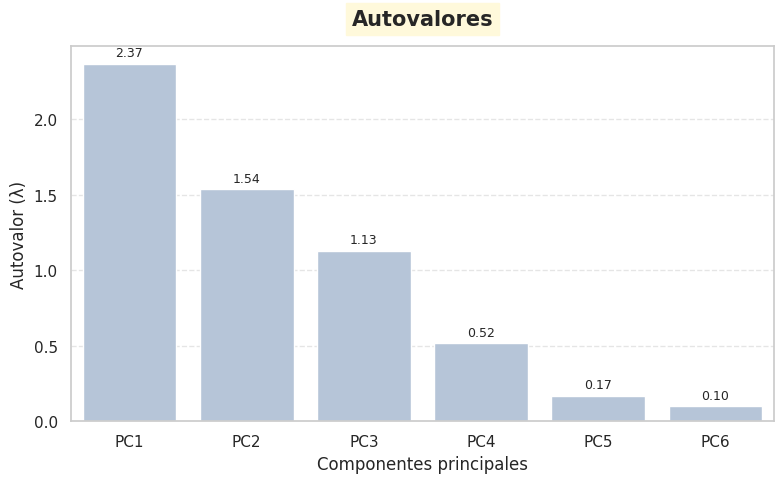

In [ ]:
# Varianza explicada
varianza = pca.explained_variance_
PVE = pca.explained_variance_ratio_
PVE_acum = np.cumsum(PVE)
componentes = [f'PC{i+1}' for i in range(len(PVE))]

# DataFrame para visualización
df_varianza = pd.DataFrame({
    'Componente': componentes,
    'Autovalor': varianza,
    'PVE': PVE,
    'PVE acumulada': PVE_acum
})

print("Matriz resumen de varianza explicada:\n")
print(df_varianza.round(3))

# Gráfico
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Componente', y='Autovalor', data=df_varianza, color='lightsteelblue')
for i, v in enumerate(df_varianza['Autovalor']):
    ax.text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=9)
plt.title("Autovalores", fontsize=15, fontweight="bold", backgroundcolor="#fff9db", pad=15)
plt.ylabel("Autovalor (λ)")
plt.xlabel("Componentes principales")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()